# Debiasing the Sinkhorn Cost by Point Optimization

The raw entropic OT cost has a non-zero self-cost and, for large $\varepsilon$, behaves like a linear functional of the moving measure.  This notebook illustrates the bias by optimizing the locations of a discrete measure
$$
\alpha_n = \frac1n\sum_{i=1}^n \delta_{x_i}
$$
against a fixed two-Gaussian target density $\beta$.  We compare gradient descent on the entropic cost $\MK_\c^\epsilon(\alpha_n,\beta)$ with gradient descent on the debiased Sinkhorn divergence
$$
\bar\MK_\c^\epsilon(\alpha_n,\beta)
= \MK_\c^\epsilon(\alpha_n,\beta)
-\frac12\MK_\c^\epsilon(\alpha_n,\alpha_n)
-\frac12\MK_\c^\epsilon(\beta,\beta).
$$
Only the source points move; the target is shown as smooth red level sets.  The source and target quadrature clouds are deterministic low-discrepancy Gaussian-mixture samples, which avoids accidental point pile-ups in the small-$\epsilon$ panels while keeping the notebook lightweight.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.special import erfinv, logsumexp

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    figure_dir,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "sinkhorn-divergence-debiasing"
OUT = figure_dir(NAME)
rng = np.random.default_rng(2029)


## Target density and quadrature

The displayed target is a continuous Gaussian mixture.  For the numerical Sinkhorn objectives, the same density is represented by a fixed low-discrepancy quadrature cloud obtained by mapping a Hammersley-type grid through Gaussian quantiles.  This is more even than pseudo-random sampling and makes the finite-particle optimization visually stable.


In [2]:
means = np.array([[-0.48, -0.13], [0.50, 0.16]])
scales = np.array([[0.34, 0.25], [0.37, 0.28]])
weights = np.array([0.44, 0.56])


def radical_inverse(n, base=2):
    seq = np.zeros(n)
    denom = 1.0
    idx = np.arange(1, n + 1)
    while np.any(idx):
        idx, rem = divmod(idx, base)
        denom *= base
        seq += rem / denom
    return seq


def normal_cloud(count, mu, sig, offset=0, scale_factor=1.0):
    u1 = (np.arange(count) + 0.5) / count
    u2 = (radical_inverse(count, base=2) + 0.38196601125 * offset) % 1.0
    U = np.clip(np.column_stack([u1, u2]), 1e-4, 1 - 1e-4)
    Z = np.sqrt(2.0) * erfinv(2.0 * U - 1.0)
    return mu + scale_factor * sig * Z


def mixture_cloud(m=160, scale_factor=1.0):
    counts = np.floor(m * weights).astype(int)
    counts[-1] += m - counts.sum()
    parts = [normal_cloud(count, means[k], scales[k], offset=k + 1, scale_factor=scale_factor)
             for k, count in enumerate(counts)]
    return np.vstack(parts)


def target_density_grid(res=180):
    u = np.linspace(-1.35, 1.38, res)
    v = np.linspace(-0.96, 1.02, res)
    U, V = np.meshgrid(u, v)
    Z = np.zeros_like(U)
    for w, mu, sig in zip(weights, means, scales):
        dx = (U - mu[0]) / sig[0]
        dy = (V - mu[1]) / sig[1]
        Z += w * np.exp(-0.5 * (dx**2 + dy**2)) / (2 * np.pi * sig[0] * sig[1])
    return U, V, Z


Y = mixture_cloud(m=176, scale_factor=1.0)
b = np.full(len(Y), 1 / len(Y))
U, V, Z = target_density_grid()
window = (-1.48, 1.50, -1.10, 1.16)


## Sinkhorn gradients

For the quadratic cost $c(x,y)=\|x-y\|^2/2$, the envelope theorem gives the gradient with respect to a moving source point:
$$
\nabla_{x_i}\operatorname{OT}_\varepsilon(\alpha_n,\beta)
= \sum_j P_{ij}(x_i-y_j).
$$
For the self-cost $\operatorname{OT}_\varepsilon(\alpha_n,\alpha_n)$, the same point appears in both marginals, so both the row and column contributions are included.


In [3]:
def squared_cost(X, Y):
    diff = X[:, None, :] - Y[None, :, :]
    return 0.5 * np.sum(diff * diff, axis=2)


def sinkhorn_plan(X, Y, eps, a=None, b=None, n_iter=None):
    n, m = len(X), len(Y)
    if a is None:
        a = np.full(n, 1 / n)
    if b is None:
        b = np.full(m, 1 / m)
    if n_iter is None:
        n_iter = 150 if eps < 0.08 else 80
    loga = np.log(a)
    logb = np.log(b)
    C = squared_cost(X, Y)
    f = np.zeros(n)
    g = np.zeros(m)
    for _ in range(n_iter):
        f = -eps * logsumexp(logb[None, :] + (g[None, :] - C) / eps, axis=1)
        g = -eps * logsumexp(loga[:, None] + (f[:, None] - C) / eps, axis=0)
    logP = loga[:, None] + logb[None, :] + (f[:, None] + g[None, :] - C) / eps
    return np.exp(np.clip(logP, -745, 40))


def cross_velocity(X, eps):
    a = np.full(len(X), 1 / len(X))
    P = sinkhorn_plan(X, Y, eps, a=a, b=b)
    grad = np.einsum("ij,ijd->id", P, X[:, None, :] - Y[None, :, :])
    return grad / a[:, None]


def self_velocity(X, eps):
    a = np.full(len(X), 1 / len(X))
    P = sinkhorn_plan(X, X, eps, a=a, b=a)
    diff = X[:, None, :] - X[None, :, :]
    row_grad = np.einsum("ij,ijd->id", P, diff)
    # The same moving atom also appears as a target location; this derivative
    # has the opposite sign of diff_{ik}=x_i-x_k.
    col_grad = -np.einsum("ik,ikd->kd", P, diff)
    return (row_grad + col_grad) / a[:, None]


def objective_velocity(X, eps, debiased):
    v = cross_velocity(X, eps)
    if debiased:
        v = v - 0.5 * self_velocity(X, eps)
    return v


## Four small optimizations

All panels start from the same compact cloud, sampled by the same deterministic mixture rule as the target.  The learning rate is gently decayed during the iterations.  The large-$\epsilon$ entropic cost moves points toward a single barycentric blob, whereas the debiased objective preserves the two overlapping target modes.


In [4]:
def initial_cloud(n_points=156):
    X0 = mixture_cloud(m=n_points, scale_factor=0.92)
    idx = np.arange(len(X0))
    # A tiny deterministic perturbation breaks exact symmetries without changing the cloud shape.
    X0 = X0 + 0.006 * np.column_stack([np.sin(17.0 * idx), np.cos(19.0 * idx)])
    return X0


X_INIT = initial_cloud()


def adam_optimize(eps, debiased, n_steps=240, lr=0.006, confinement=0.012):
    X = X_INIT.copy()
    m = np.zeros_like(X)
    v = np.zeros_like(X)
    beta1, beta2 = 0.88, 0.97
    for t in range(1, n_steps + 1):
        grad = objective_velocity(X, eps, debiased)
        # A mild confinement prevents a few atoms from leaving the displayed window.
        grad += confinement * X
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad * grad
        mh = m / (1 - beta1**t)
        vh = v / (1 - beta2**t)
        step = lr * (0.35 + 0.65 * (1 - t / n_steps))
        X -= step * mh / (np.sqrt(vh) + 1e-8)
        X[:, 0] = np.clip(X[:, 0], window[0] + 0.025, window[1] - 0.025)
        X[:, 1] = np.clip(X[:, 1], window[2] + 0.025, window[3] - 0.025)
    return X


configs = {
    "raw-small": dict(eps=0.024, debiased=False, n_steps=180, lr=0.0035),
    "debiased-small": dict(eps=0.024, debiased=True, n_steps=240, lr=0.0045),
    "raw-large": dict(eps=0.70, debiased=False, n_steps=120, lr=0.0100),
    "debiased-large": dict(eps=0.70, debiased=True, n_steps=300, lr=0.0130),
}
results = {name: adam_optimize(**cfg) for name, cfg in configs.items()}
for name, X in results.items():
    nn = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=2))
    nn[nn == 0] = np.inf
    print(
        f"{name:15s} center=({X[:,0].mean():+.3f},{X[:,1].mean():+.3f})  "
        f"spread={np.sqrt(np.var(X, axis=0).sum()):.3f}  "
        f"median-nn={np.median(nn.min(axis=1)):.3f}"
    )


raw-small       center=(+0.070,+0.032)  spread=0.633  median-nn=0.003
debiased-small  center=(+0.070,+0.032)  spread=0.667  median-nn=0.073
raw-large       center=(+0.068,+0.033)  spread=0.136  median-nn=0.000
debiased-large  center=(+0.070,+0.032)  spread=0.659  median-nn=0.088


## Export panels

Each panel shows the same target contours and one optimized point cloud.  The panel names and mathematical explanation are supplied by LaTeX, not embedded inside the PDF.


In [5]:
def draw_panel(X, path):
    fig, ax = plt.subplots(figsize=(1.78, 1.43))
    levels = np.linspace(Z.max() * 0.10, Z.max() * 0.86, 6)
    ax.contourf(U, V, Z, levels=levels, colors=[RED], alpha=0.045)
    ax.contour(U, V, Z, levels=levels, colors=RED, linewidths=0.52, alpha=0.58)
    ax.scatter(
        X[:, 0],
        X[:, 1],
        s=DIRAC_MARKER_SIZE * 0.22,
        marker="o",
        color=BLUE,
        edgecolor="none",
        linewidth=0,
        alpha=0.84,
        zorder=4,
    )
    ax.set_xlim(window[0], window[1])
    ax.set_ylim(window[2], window[3])
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, path, pad_inches=0.025)
    plt.close(fig)


for name, X in results.items():
    draw_panel(X, OUT / f"{name}.pdf")


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


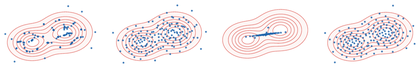

In [6]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/sinkhorn-divergence-debiasing.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/sinkhorn-divergence-debiasing.png")
display(Image(filename=str(_thumb)))
